In [4]:
import urllib.request, zipfile, os
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity



---



# 1. **Load the Data**:

Using the MovieLens 100K Dataset.
i) Data sample is already clean, so we won't need to account for null values
ii) contains 1-5 star ratings.


In [5]:
if not os.path.exists('ml-100k/u.data'):
    urllib.request.urlretrieve('https://files.grouplens.org/datasets/movielens/ml-100k.zip', 'ml-100k.zip')
    zipfile.ZipFile('ml-100k.zip').extract('ml-100k/u.data')

df = pd.read_csv('ml-100k/u.data', sep='\t',         #MovieLens 100K is a tab separated file
                      names=['user_id', 'movie_id', 'rating', 'timestamp'],       #the original u.data file doesnt have a header at top. so this gives them header names
)

In [6]:
print(df.shape)
df.head()

(100000, 4)


,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [7]:
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


,0
user_id,0
movie_id,0
rating,0
timestamp,0




---



# 2. **Train Test Split**:

Split the data in 80-20 before performing EDA, to prevent data-leakage.
We split the data such that we use a Temporal Split- train on older ratings, test on newer ratings -> We require the timestamps to be arranged in ascending order

In [8]:
df = df.sort_values('timestamp').reset_index(drop=True)

In [9]:
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

In [10]:
#Dropping timestamp column
train_df = train_df.drop(columns=['timestamp'])
test_df = test_df.drop(columns=['timestamp'])

print(f"Train size: {len(train_df)} rows | Test size: {len(test_df)} rows")

Train size: 80000 rows | Test size: 20000 rows


Cons of a time-based (Temporal) Split of train-test: If a user only rated movies during the final 20% of the timeline, they will only be in the test set, creating a "cold start" user problem for matrix factorization



---



# 3. **EDA**:

Tackling the problem of User Behaviour. Some users are harsher critics(eg: give 1 star to a movie), some users are more easygoing(eg: give 4 stars to the same movie). THUS, we focus on deviation of a user from the average of ratings given by them.


In [11]:
global_train_mean = train_df['rating'].mean()

# Calculate user mean and subtract it directly
train_df['rating_centered'] = train_df['rating'] - train_df.groupby('user_id')['rating'].transform('mean')

# Save the user means in a separate variable for later use during prediction
train_user_means = train_df.groupby('user_id')['rating'].mean()

print("--- Data Centered Safely ---")
print(train_df[['user_id', 'movie_id', 'rating', 'rating_centered']].head())


--- Data Centered Safely ---
   user_id  movie_id  rating  rating_centered
0      259       255       4         0.130435
1      259       286       4         0.130435
2      259       298       4         0.130435
3      259       185       4         0.130435
4      259       173       4         0.130435




---



# 4. **Memory-Based Approach**:

We map our long dataframe into a wide matrix. The unobserved interactions are filled with 0 (since the mean is subtracted, 0 represents the neutral baseline).

Changing into a User-Item Matrix

In [12]:
# 1. Map IDs to matrix indices to ensure no out-of-bounds indexing
unique_users = sorted(df['user_id'].unique())
unique_movies = sorted(df['movie_id'].unique())

# Mapping user ID to matrix row number(0-based indexing)
user_to_idx = {uid: i for i, uid in enumerate(unique_users)}
movie_to_idx = {mid: i for i, mid in enumerate(unique_movies)}

n_users = len(unique_users)
n_movies = len(unique_movies)

# Create Empty matrices
R_train = np.zeros((n_users, n_movies))
R_test = np.zeros((n_users, n_movies))

# Fill training matrix with centered ratings
for row in train_df.itertuples():           # goes through every single row
    u_idx = user_to_idx[row.user_id]        # finds user's matrix row
    m_idx = movie_to_idx[row.movie_id]        # finds user's matrix column
    R_train[u_idx, m_idx] = row.rating_centered         # put the rating into the matrix

# Fill test matrix with original ratings (for evaluation)
for row in test_df.itertuples():
    u_idx = user_to_idx[row.user_id]
    m_idx = movie_to_idx[row.movie_id]
    R_test[u_idx, m_idx] = row.rating


Implement User-User Cosine. We compute user similarities based on their centered rating vectors and predict the test set ratings

In [13]:
def predict_memory_based(R_train, train_user_means, global_mean):         # Global mean is a fallback if we don't have a particular user's mean
    # Find Cosine Similarity between users. It treats the rows as vectors, and finds similarity between them.
    user_sim = cosine_similarity(R_train)

    # Avoid self-similarity bias by setting diagonal to 0
    np.fill_diagonal(user_sim, 0)

    # Keep absolute values for normalizing denominators
    eps = 1e-9
    user_sim_abs = np.abs(user_sim)

    # Predict deviations: (Sim dot R) / Sum of absolute similarities
    predicted_deviations = np.dot(user_sim, R_train) / (np.dot(user_sim_abs, (R_train != 0).astype(float)) + eps)       # We create a mask of 0,1, which tells if rating-exists

    # Getting our Original scale back, by adding back the mean
    predictions = np.zeros_like(R_train)
    for u in range(n_users):
        u_id = unique_users[u]
        u_mean = train_user_means.get(u_id, global_mean)
        predictions[u, :] = predicted_deviations[u, :] + u_mean

    return predictions

mem_preds = predict_memory_based(R_train, train_user_means, global_train_mean)




---



# 5. **Model-Based Approach**:

Matrix Factorization via SGD (including Regularization).
We decompose the matrix into User matrix and Item matrix, optimized using Stochastic Gradient Descent.
Say P is the User Matrix which shows the tastes of users. And Q is the Movie Matrix which shows the genres/type of the movie.


In [14]:
def train_matrix_factorization(R_train, train_df, train_user_means, global_mean, k=20, lr=0.005, reg=0.02, epochs=30):
    # Initialize k Latent Factors randomly
    P = np.random.normal(scale=1.0/k, size=(n_users, k))   # Scale ensures that 68% of the generated datapoints fall roughly within 1/k deviation of the mean
    Q = np.random.normal(scale=1.0/k, size=(n_movies, k))

    # Extract training samples for fast row-by-row SGD iteration
    samples = []
    for row in train_df.itertuples():
        u_idx = user_to_idx[row.user_id]
        m_idx = movie_to_idx[row.movie_id]
        samples.append((u_idx, m_idx, row.rating_centered))

    # SGD Loop
    for epoch in range(epochs):
        np.random.shuffle(samples)          # In each epoch, the samples are shuffled to ensure random updates, helps prevent cycles and speeds up convergence
        for u, i, r_centered in samples:
            # Predict centered interaction via dot product
            pred_centered = np.dot(P[u, :], Q[i, :])
            err = r_centered - pred_centered

            # Update Latent Vectors concurrently using Gradients + L2 Regularization
            p_old = P[u, :].copy()
            P[u, :] += lr * (err * Q[i, :] - reg * P[u, :])
            Q[i, :] += lr * (err * p_old - reg * Q[i, :])

    # Reconstruct whole centered matrix and add back user averages
    R_pred_centered = np.dot(P, Q.T)
    predictions = np.zeros_like(R_train)
    for u in range(n_users):
        u_id = unique_users[u]
        u_mean = train_user_means.get(u_id, global_mean)
        predictions[u, :] = R_pred_centered[u, :] + u_mean

    return predictions

model_preds = train_matrix_factorization(R_train, train_df, train_user_means, global_train_mean, k=30, epochs=30)




---



# 6. **Evaluation Metrics & Performance Comparison**:

Evaluate against the non-zero cells of our R_test matrix using RMSE and MAE.


In [16]:
def evaluate_model(predictions, R_test):
    # Focus only where test values exist
    idx = R_test > 0
    actuals = R_test[idx]
    preds = predictions[idx]

    # Clip predictions to legal boundaries [1, 5]
    preds = np.clip(preds, 1, 5)

    rmse = np.sqrt(np.mean((actuals - preds) ** 2))
    mae = np.mean(np.abs(actuals - preds))
    return rmse, mae

mem_rmse, mem_mae = evaluate_model(mem_preds, R_test)
model_rmse, model_mae = evaluate_model(model_preds, R_test)

# Summary DataFrame
results_df = pd.DataFrame({
    'Metric': ['RMSE (Lower is Better)', 'MAE (Lower is Better)'],
    'Memory-Based (Cosine)': [mem_rmse, mem_mae],
    'Model-Based (MF-SGD)': [model_rmse, model_mae]
})


,Metric,Memory-Based (Cosine),Model-Based (MF-SGD)
0,RMSE (Lower is Better),1.1122,1.1080
1,MAE (Lower is Better),0.9323,0.9289


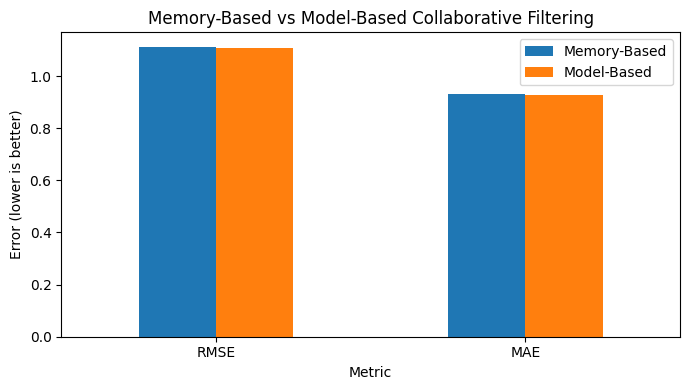

Lower RMSE: Model-Based (MF-SGD)
Lower MAE: Model-Based (MF-SGD)


In [18]:
# Display a short numerical comparison
results_display = results_df.copy()
results_display[['Memory-Based (Cosine)', 'Model-Based (MF-SGD)']] = results_display[['Memory-Based (Cosine)', 'Model-Based (MF-SGD)']].round(4)
display(results_display)

# Plot 1: RMSE and MAE comparison
import matplotlib.pyplot as plt

plot_df = pd.DataFrame({
    'Metric': ['RMSE', 'MAE'],
    'Memory-Based': [mem_rmse, mem_mae],
    'Model-Based': [model_rmse, model_mae]
})

ax = plot_df.set_index('Metric').plot(kind='bar', figsize=(7, 4))
ax.set_ylabel('Error (lower is better)')
ax.set_title('Memory-Based vs Model-Based Collaborative Filtering')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# Identify the lower-error method for each metric without hard-coding the result.
rmse_winner = 'Memory-Based (Cosine)' if mem_rmse < model_rmse else 'Model-Based (MF-SGD)'
mae_winner = 'Memory-Based (Cosine)' if mem_mae < model_mae else 'Model-Based (MF-SGD)'
print(f'Lower RMSE: {rmse_winner}')
print(f'Lower MAE: {mae_winner}')


# 6. **Conclusion**:

The two approaches make different trade-offs. **Memory-based collaborative filtering** directly uses similarities between users. Limitations - computing, low performance on sparse matries.

**Model-based collaborative filtering (MF-SGD)** learns a compact latent representation of users and movies. Better for larger and sparser recommender systems.

Thus, use a **memory-based method when direct similarity-based and ease of implementation are priorities**; prefer a **model-based method when scalability, sparse data, and learning latent user-item patterns are more important**.

C
The RMSE/MAE Table clearly states the model-based approach performs better on the MovieLens 100K dataset. Owing mainly to factors such as how sparse the dataset is.

Neither approach completely solves the **cold-start problem**: a new user or a new movie with little or no interaction history provides insufficient information for either method.